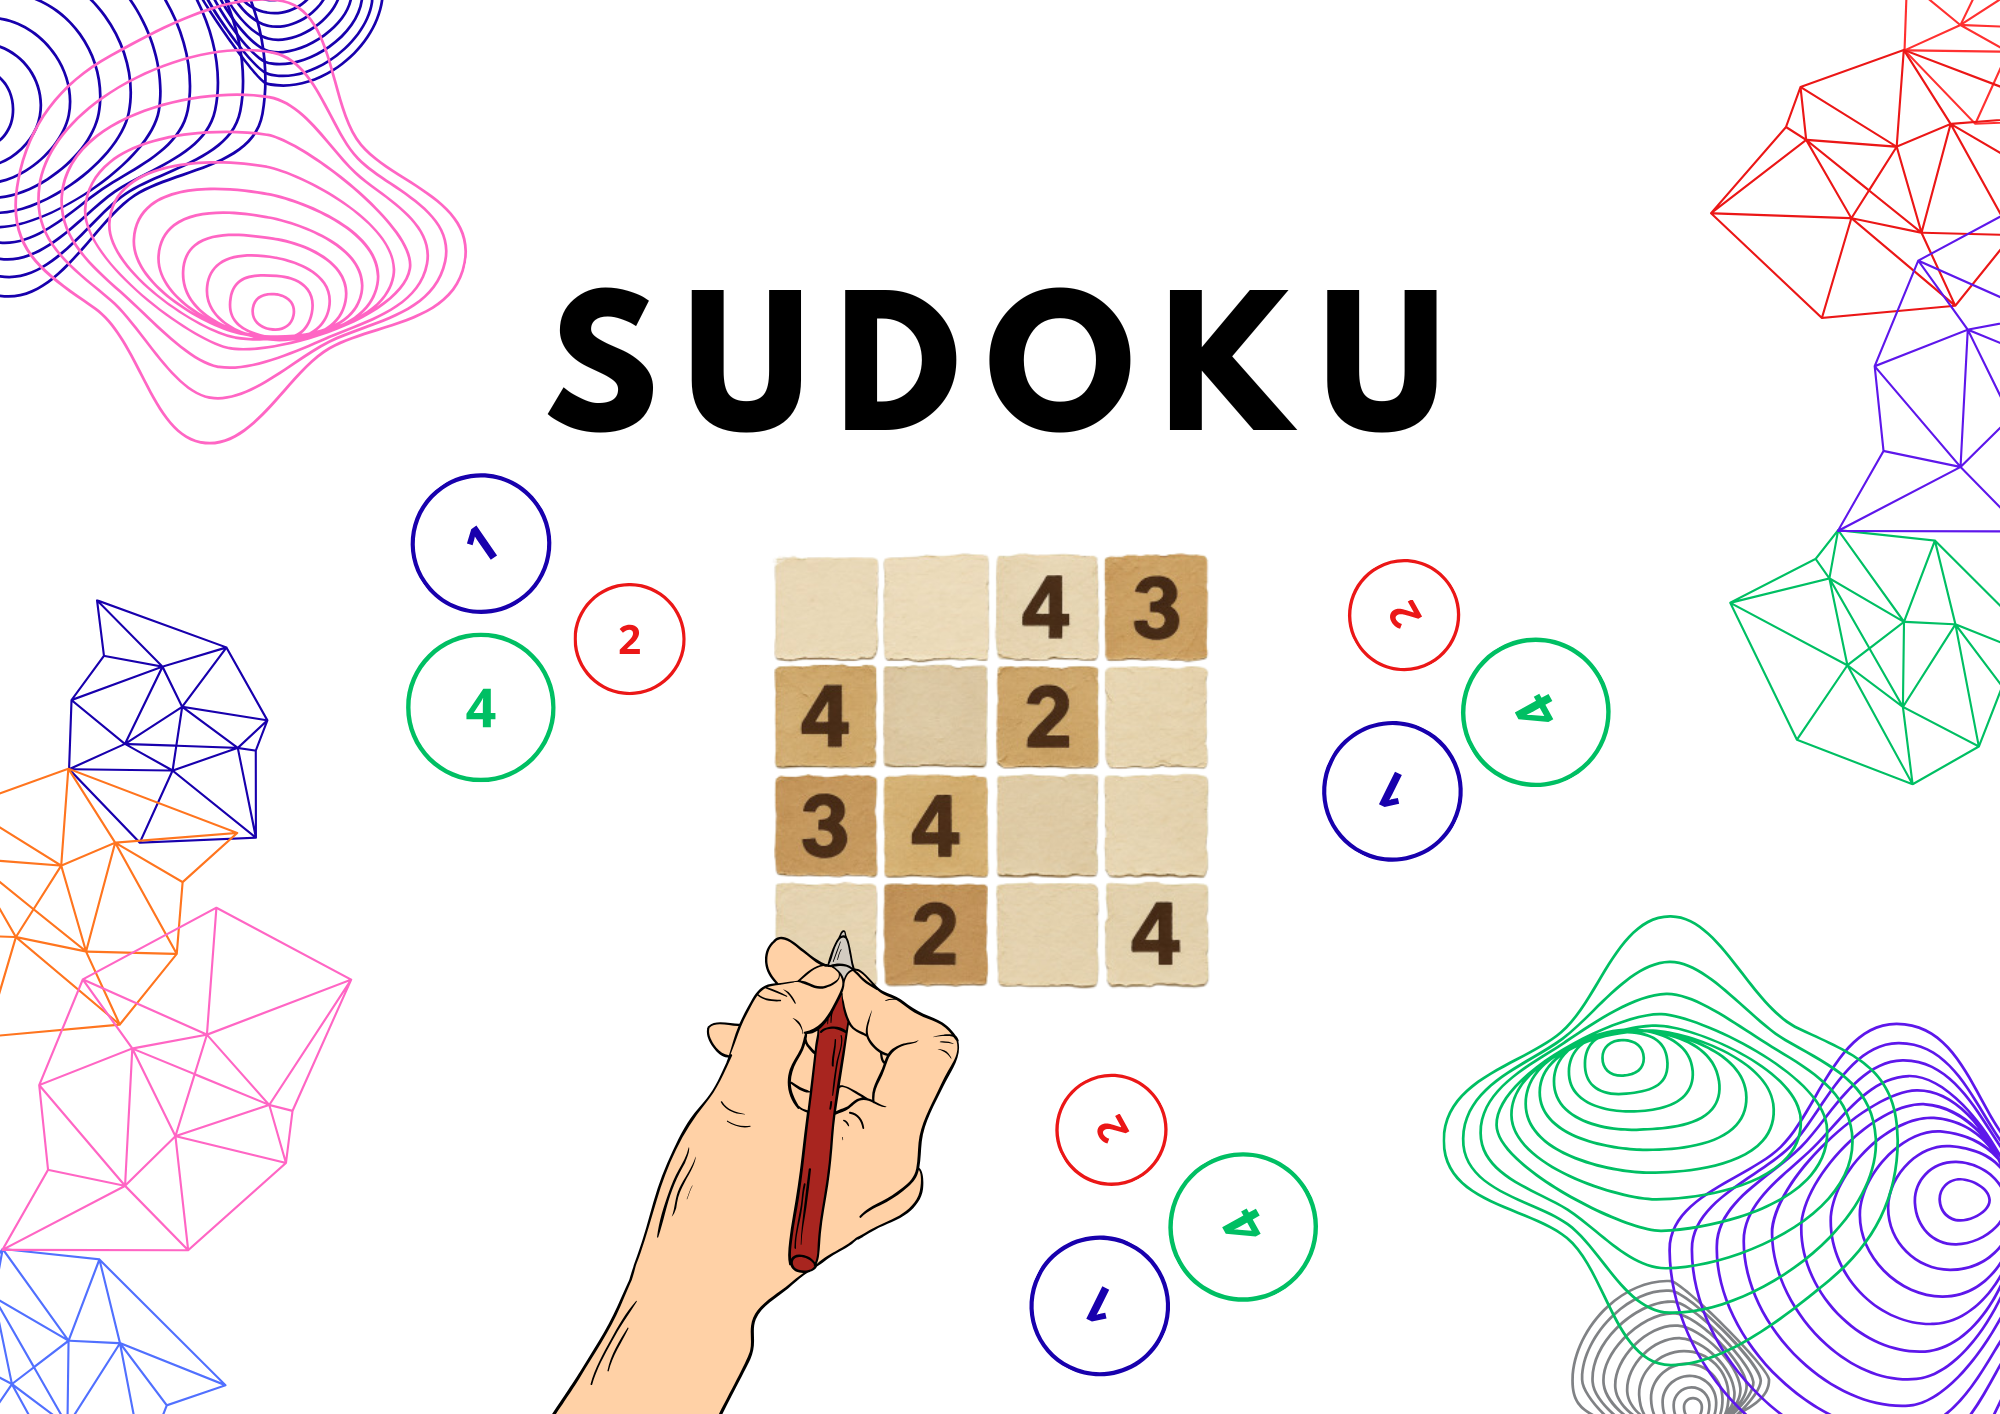

Integrantes:



1.   Arely Rubi Reyes Quiroz
2.   Gabriel Contreras Perez
1.  Kevin Brandon Perez Guerrero

Link: https://github.com/brandonguerreroo/baile


# **Descripcion del problema**

Un Sudoku es un problema logico que consiste en una cuadricula de NxM donde el objetivo es llenar de numeros la cuadricula con la condicion de que cada numero aparezaca una vez en cada fila, columna y  subcuadro.

En este proyecto, el Sudoku sera modelado como un problema de busqueda. Donde el Sudoku sera de 4x4 con subcuadros de 2x2, donde tendremos un estado inicial una cuadricula con algunas casillas llenas. Se buscara la primera casilla vacia desde arriba a la izquierda hacia abajo y de acuerdo a las condiciones del problema se buscara sus numeros legales(numeros validos), nuestra busqueda terminaria cuando todas las casillas del Sudoku estan llenas y se cumplieron las condiciones.




##**Ejemplo**
La siguiente imagen es un ejemplo de un Sudoku de 4x4, con subcuadros 2x2,donde se deberan llenar las casillas vacias con numeros del 1 al 4 y de acuerdo a las condiciones.


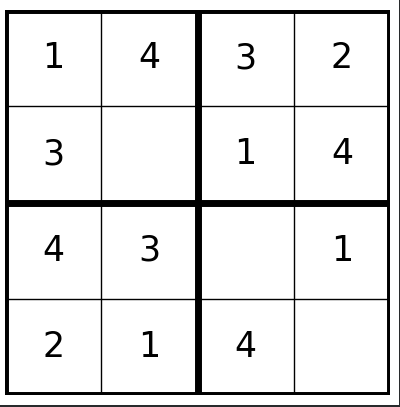

#**Modelado formal**

## **Estado**

El estado consta del tablero de Sudoku 4x4, este es una tupla de tuplas en donde cada fila representa a una fila del sudoku. Esto nos permite tener un estado el cual es hashable, lo cual es necesario para TreeSearch.

## **Sucesor**

La función sucesor está definida para encontrar el conjunto de casillas vacías en nuestro estado (tablero), mientras haya casillas vacías y encontremos la primera, haremos la búsqueda de los números legales los cuales pueden escribirse en esa casilla. Para todos los números legales, procederemos a crear un hijo (sucesor). Como estamos trabajando con tupla de tuplas, estas no se pueden modificar directamente, por lo cual es necesario convertirlas en listas primero para poder modificar el primer cero que se encuentre en el tablero. Una vez ya hayamos modificado esto, se regresa a tupla de tuplas. Nuestro costo de movimiento es de 1.

## **Meta**

Nuestra condición de meta es que el Sudoku termine resuelto, por lo tanto, nuestra meta es cuando no tenemos ningún cero en el tablero, siempre respetando que sea un tablero legal.

## **Heurística**

Se pensó de tal manera en que cada casilla vacía representa un movimiento restante para llegar a la meta. Es decir, si tenemos 8 casillas vacías, tenemos necesariamente que hacer 8 movimientos. Esto nos permite hacer que nunca sobreestime, teniendo así, una heurística admisible. Esta heurística si bien pareciera ser la correcta, no ayuda correctamente a A*.
Pensando en nuestra anterior heurística, se optó en otra que pudiera ayudar más a A* con los nodos expandidos. Nuestra segunda heurística se basa en contar la cantidad de casillas vacías las cuales sólo tienen 1 número legal. Siendo así, la resta de cantidad de casillas vacías menos la cantidad de casillas con sólo un número legal. Esta segunda heurística propuesta, ayuda bastante a A* a encontrar de mejor manera el mejor camino.


# **Estimacion del tamaño de busqueda**

La estimación del tamaño de nuestro modelo se calcula con el espacio de los estados, utilizando el factor de la ramificación (b) y por la profundidad de la solución (d).

La ramificación (b) es el promedio de opciones válidas que tenemos para llenar una casilla.  En el modelado de nuestro sudoku de 4x4, el máximo teórico es de 4 números posibles por cada casilla vacía.

Sin embargo, al aplicar las reglas del juego (no repetir el número en la misma fila ,columna o subcuadro de 2x2),  las opciones reales se reducen muy rápido. ya que cada número colocado bloquea las opciones de las demás casillas restantes.  en la teoría de nuestro sudoku  es de b= 4 en el peor de los casos por casillas.

La profundidad (d) es el número de las casillas vacías a llenar. Tomando como referencia nuestro tablero “fácil”, comenzamos con 9 casillas vacías, por lo que  d = 9.  El límite  para que la búsqueda BFS no se congele en python es de 10^6 nodos. Como máximo teórico tenemos 4^9.

para no sobrestimar la capacidad del equipo, utilizando un promedio conservador de b = 1 como escenario en el tablero “fácil”. El cálculo en nuestro escenario es la cantidad de caminos posibles que se generan  de 1^9= 1  esto se justifica por que en este caso solo por cada casilla vacía solo hay un posible número legal, lo cual es muchísimo menor que 10^6.





# **Implementacion**

In [ ]:
import urllib.request
import importlib.util
import numpy as np

from matplotlib import pyplot as plt

url = "https://raw.githubusercontent.com/kyriox/baile/master/src/SimpleSearch.py"

urllib.request.urlretrieve(url, "SimpleSearch.py")

('SimpleSearch.py', <http.client.HTTPMessage at 0x7e1a18de6d50>)

In [ ]:
import pandas as pd

In [ ]:
import SimpleSearch as sp
import time

***Representacion del estado***

In [ ]:
#Definir el estado
#sudoku para el modelado de instancia FACIL
start = sp.node(((1, 0, 3, 0),
                 (0, 4, 0, 2),
                 (0, 0, 4, 0),
                 (4, 0, 0, 1)),
                 depth=0,parent=None)
#sudoku para el modelado de instancia DIFICL
start1 = sp.node(((2, 3, 0, 0),
                  (1, 0, 0, 0),
                  (0, 0, 0, 0),
                  (3, 1, 0, 2)),
                  depth=0,parent=None)
#sudoku para el modelado de instancia MEDIA
start2 = sp.node(((1, 0, 0, 4),
                  (0, 4, 1, 0),
                  (0, 1, 4, 0),
                  (4, 0, 0, 1)),
                  depth=0,parent=None)


In [ ]:
# Funcion para graficar nuestro Sudoku
def plotSudoku(state):
  n = len(state)

  fig, ax = plt.subplots(figsize=(5, 5))
  # Hacemos los limites sean de longitud sea n.
  ax.set_xlim(0, n)
  ax.set_ylim(0, n)
  ax.set_aspect("equal")

  # Grafica las lineas del Sudoku.
  for i in range(n + 1):
      grosor = 5 if i % 2 == 0 else 1
      ax.plot([0, n], [i, i], color="black", linewidth=grosor)
      ax.plot([i, i], [0, n], color="black", linewidth=grosor)
  # Recorremos el tablero Sudoku
  for fila in range(n):
      for columna in range(n):
        # Sólo ponemos en el Sudoku los números diferentes de '0'
        if state[fila][columna] != 0:
          ax.text(columna + 0.5, n - fila - 0.5, str(state[fila][columna]), ha="center", va="center", fontsize=25)
  ax.axis("off") # Desactivamos los ejes
  plt.show()

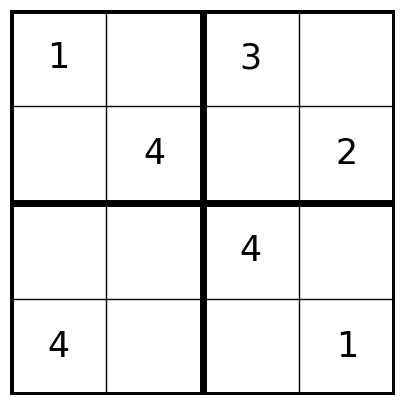

In [ ]:
plotSudoku(start.state)

In [ ]:
# Función que regresa una lista de tuplas con las coordenadas
# de los estados vacíos.
def encontrarCasillaVacias(state):
  n = len(state)
  vacios = []
  for i in range(n):
    for j in range(n):
      if state[i][j] == 0:
        vacios.append((i,j))
  return vacios

In [ ]:
# Nos regresa la casilla diagonal en el subcuadro
def casillaSubcuadro(state, fila, columna):
  cuadrante = fila // 2 * 2 + columna // 2 # Calcular el cuadrante

  # Coordenadas por cuadrante
  arreglos = (
      ((0,0), (0,1), (1,0), (1,1)),
      ((0,2), (0,3), (1,2), (1,3)),
      ((2,0), (2,1), (3,0), (3,1)),
      ((2,2), (2,3), (3,2), (3,3))
  )
  # Recorremos las coordenadas del cuadrante
  for coordenada in arreglos[cuadrante]:
    i = coordenada[0]
    j = coordenada[1]
    if fila != i and columna != j:
        return coordenada

In [ ]:
# Regresa lista con numeros legales para esa casilla
def numerosLegales(state, fila, columna):
  legales = []
  n = len(state)
  cs = casillaSubcuadro(state,fila,columna)
  # Recorremos los números posibles (1,2,3,4).
  for numero in range(1, n + 1):
    repetido = False
    for i in range(n):
      # Comprobamos si el numero está en fila, columna o diagonal del subcuadro
      if numero == state[i][columna] or numero == state[fila][i] or numero == state[cs[0]][cs[1]]:
        repetido = True
    if not repetido:
      legales.append(numero)
  return legales

***Funcion sucesor***

In [ ]:
# Genera los estados sucesores
def sucesoresSudoku(nodo):
  S=[]
  st = nodo.state
  casillasVacias = encontrarCasillaVacias(nodo.state)
  # Comprobamos que al menos haya una casilla vacía.
  if len(casillasVacias) > 0:
    # Obtenemos primera fila y columna de casilla vacía.
    fila = casillasVacias[0][0]
    columna = casillasVacias[0][1]
    # Calculamos los números legales para esa casilla.
    legales = numerosLegales(nodo.state, fila, columna)
    for numero in legales:
      # Crea copia de estado actual convirtiendo cada fila en una lista.
      nuevo = [list(fila) for fila in st]
      nuevo[fila][columna] = numero
      # Convertimos cada fila en una tupla.
      nuevoNodo = tuple((tuple(fila) for fila in nuevo))
      # Creamos nodo con el estado modificado.
      S.append(sp.node(nuevoNodo, depth=nodo.depth + 1, parent = nodo))
    return S

***Heuristicas***

In [ ]:
# Regresa la cantidad de casillas vacías.
def heuristica1(*nodos):
  nodo=nodos[0]
  cantidadDeVacios = len(encontrarCasillaVacias(nodo.state))
  return cantidadDeVacios

In [ ]:
# Cuenta casillas vacías y cuántas tienen sólo un numero legal.
def heuristica2(*nodos):
  nodo = nodos[0]
  numLegales = 0
  casillaVacia = encontrarCasillaVacias(nodo.state)
  n = len(casillaVacia)
  # Recorremos todas las casillas vacías
  for i in range(n):
    # Obtenemos fila y columna de la casilla actual
    fila = casillaVacia[i][0]
    columna = casillaVacia[i][1]
    legales = numerosLegales(nodo.state, fila, columna)
    if len(legales) == 1:
      numLegales += 1
  return n - numLegales

state: ((1, 2, 3, 0), (0, 4, 0, 2), (0, 0, 4, 0), (4, 0, 0, 1)), op: , depth: 1, g: 0, h: 0


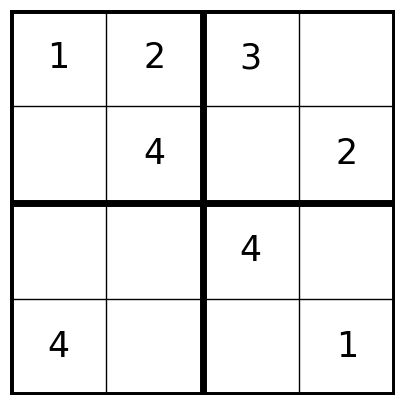

state: ((1, 2, 3, 4), (0, 4, 0, 2), (0, 0, 4, 0), (4, 0, 0, 1)), op: , depth: 2, g: 0, h: 0


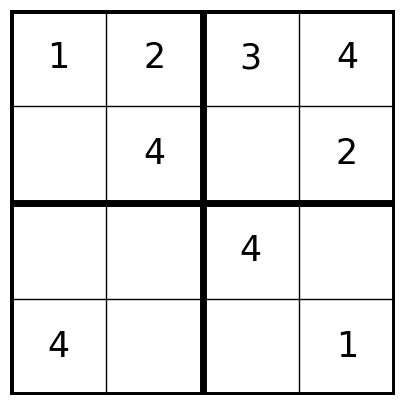

state: ((1, 2, 3, 4), (3, 4, 0, 2), (0, 0, 4, 0), (4, 0, 0, 1)), op: , depth: 3, g: 0, h: 0


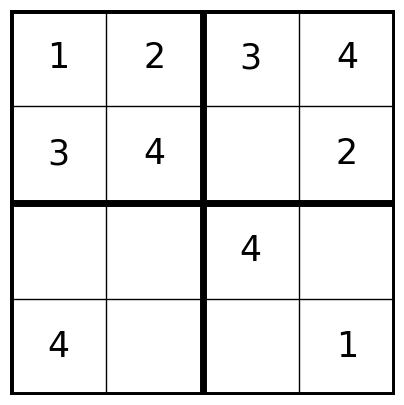

In [ ]:
sucesores = sucesoresSudoku(start)
for s in sucesores:
  print(s)
plotSudoku(sucesores[0].state)
sucesor = sucesoresSudoku(sucesores[0])
for s in sucesor:
  print(s)
  plotSudoku(sucesor[0].state)
  sucesor1 = sucesoresSudoku(sucesor[0])
  for s in sucesor1:
    print(s)
    plotSudoku(sucesor1[0].state)
    sucesor2 = sucesoresSudoku(sucesor1[0])


***Condicion meta***

In [ ]:
# Funcion que determina si un nodo es uan solución.
def meta(*nodos):
  st=nodos[0]
  # Si no hay casillas vacías el sudoku está completo.
  return encontrarCasillaVacias(st.state) == []

In [ ]:
casillaSubcuadro(start.state,0,0)

(1, 1)

In [ ]:
encontrarCasillaVacias(start.state)

[(0, 1), (0, 3), (1, 0), (1, 2), (2, 0), (2, 1), (2, 3), (3, 1), (3, 2)]

# **Experimentos (protocolo experimental)**

Para comparar las estrategias se utilizaron tres instancias de Sudoku 4×4 en una instancia fácil, media y difícil. Para cada instancia se ejecutaron BFS, DFS, A* con h(n)=0, A* con H1 y A* con H2. Todas las búsquedas utilizaron un límite fijo de max_iter=10,000 y fueron ejecutadas en la misma computadora. Para cada ejecución se registraron los nodos expandidos, tiempo de ejecución, longitud de la solución y costo acumulado g.

In [ ]:
import sys
import platform

print("Python:", sys.version)
print("Sistema operativo:", platform.platform())
print("Procesador:", platform.processor())


Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Sistema operativo: Linux-6.6.122+-x86_64-with-glibc2.39
Procesador: x86_64


### **Sudoku facil**

In [ ]:
bfs=sp.TreeSearch(start, sucesoresSudoku, meta, strategy="bfs")
dfs=sp.TreeSearch(start, sucesoresSudoku, meta, strategy="dfs")
bas=sp.TreeSearch(start, sucesoresSudoku, meta, strategy="a*", heuristic=heuristica2)
bas0=sp.TreeSearch(start, sucesoresSudoku, meta, strategy="a*", heuristic=None)
h1=sp.TreeSearch(start, sucesoresSudoku, meta, strategy="a*", heuristic=heuristica1)
t0 = time.time()

rBFS = bfs.find(max_iter=10000) # devuelve None si no encuentra solucion
nodosBFS = bfs.iterations # nodos expandidos
tiempoBFS = time.time() - t0
t0 = time.time()
rDFS = dfs.find(max_iter=10000)
nodosDFS = dfs.iterations
tiempoDFS = time.time() - t0
t0 = time.time()
rBAS = bas.find(max_iter=10000)
nodosBAS = bas.iterations
tiempoBAS = time.time() - t0
t0 = time.time()
rBAS0 = bas0.find(max_iter=10000)
nodosBAS0 = bas0.iterations
tiempoBAS0 = time.time() - t0

t0 = time.time()
rh1 = h1.find(max_iter=10000) # devuelve None si no encuentra solucion
nodosh1 = h1.iterations # nodos expandidos
tiempoh1 = time.time() - t0

longBFS = len(rBFS.getPath()) - 1 # numero de movimientos
longDFS = len(rDFS.getPath()) - 1
longBAS = len(rBAS.getPath()) - 1
longBAS0 = len(rBAS0.getPath()) - 1
longh1 = len(rh1.getPath()) - 1

table = pd.DataFrame({"Instancia":["Facil","Facil","Facil","Facil","Facil"],
                      "Estrategia":["BFS","DFS","A*(h=0)","A*(H1)","A*(H2)"],
                      "Nodos expandidos": [nodosBFS,nodosDFS,nodosBAS0,nodosh1,nodosBAS],
                      "Tiempo(s)": [tiempoBFS,tiempoDFS,tiempoBAS0,tiempoh1,tiempoBAS],
                      "Longitud":[longBFS,longDFS,longBAS0,longh1,longBAS],
                      "Costo g":[rBFS.cost,rDFS.cost,rBAS0.cost,rh1.cost,rBAS.cost]})
table
tabla_facil = table.copy()

### **Sudoku medio**

In [ ]:
bfs=sp.TreeSearch(start2, sucesoresSudoku, meta, strategy="bfs")
dfs=sp.TreeSearch(start2, sucesoresSudoku, meta, strategy="dfs")
bas=sp.TreeSearch(start2, sucesoresSudoku, meta, strategy="a*", heuristic=heuristica2)
bas0=sp.TreeSearch(start2, sucesoresSudoku, meta, strategy="a*", heuristic=None)
h1=sp.TreeSearch(start2, sucesoresSudoku, meta, strategy="a*", heuristic=heuristica1)

t0 = time.time()
rBFS = bfs.find(max_iter=10000) # devuelve None si no encuentra solucion
nodosBFS = bfs.iterations # nodos expandidos
tiempoBFS = time.time() - t0

t0 = time.time()
rDFS = dfs.find(max_iter=10000)
nodosDFS = dfs.iterations
tiempoDFS = time.time() - t0

t0 = time.time()
rBAS = bas.find(max_iter=10000)
nodosBAS = bas.iterations
tiempoBAS = time.time() - t0

t0 = time.time()
rBAS0 = bas0.find(max_iter=10000)
nodosBAS0 = bas0.iterations
tiempoBAS0 = time.time() - t0

t0 = time.time()
rh1 = h1.find(max_iter=10000) # devuelve None si no encuentra solucion
nodosh1 = h1.iterations # nodos expandidos
tiempoh1 = time.time() - t0


longBFS = len(rBFS.getPath()) - 1 # numero de movimientos
longDFS = len(rDFS.getPath()) - 1
longBAS = len(rBAS.getPath()) - 1
longBAS0 = len(rBAS0.getPath()) - 1
longh1 = len(rh1.getPath()) - 1

table = pd.DataFrame({"Instancia":["Medio","Medio","Medio","Medio","Medio"],
                      "Estrategia":["BFS","DFS","A*(h=0)","A*(H1)","A*(H2)"],
                      "Nodos expandidos": [nodosBFS,nodosDFS,nodosBAS0,nodosh1,nodosBAS],
                      "Tiempo(s)": [tiempoBFS,tiempoDFS,tiempoBAS0,tiempoh1,tiempoBAS],
                      "Longitud":[longBFS,longDFS,longBAS0,longh1,longBAS],
                      "Costo g":[rBFS.cost,rDFS.cost,rBAS0.cost,rh1.cost,rBAS.cost]})
table
tabla_medio = table.copy()

### **Sudoku dificil**

In [ ]:
bfs=sp.TreeSearch(start1, sucesoresSudoku, meta, strategy="bfs")
dfs=sp.TreeSearch(start1, sucesoresSudoku, meta, strategy="dfs")
bas=sp.TreeSearch(start1, sucesoresSudoku, meta, strategy="a*", heuristic=heuristica2)
bas0=sp.TreeSearch(start1, sucesoresSudoku, meta, strategy="a*", heuristic=None)
h1=sp.TreeSearch(start1, sucesoresSudoku, meta, strategy="a*", heuristic=heuristica1)
t0 = time.time()
rBFS = bfs.find(max_iter=10000) # devuelve None si no encuentra solucion
nodosBFS = bfs.iterations # nodos expandidos
tiempoBFS = time.time() - t0

t0 = time.time()
rDFS = dfs.find(max_iter=10000)
nodosDFS = dfs.iterations
tiempoDFS = time.time() - t0
t0 = time.time()
rBAS = bas.find(max_iter=10000)
nodosBAS = bas.iterations
tiempoBAS = time.time() - t0
t0 = time.time()
rBAS0 = bas0.find(max_iter=10000)
nodosBAS0 = bas0.iterations
tiempoBAS0 = time.time() - t0

t0 = time.time()
rh1 = h1.find(max_iter=10000) # devuelve None si no encuentra solucion
nodosh1 = h1.iterations # nodos expandidos
tiempoh1 = time.time() - t0


longBFS = len(rBFS.getPath()) - 1 # numero de movimientos
longDFS = len(rDFS.getPath()) - 1
longBAS = len(rBAS.getPath()) - 1
longBAS0 = len(rBAS0.getPath()) - 1
longh1 = len(rh1.getPath()) - 1

table = pd.DataFrame({"Instancia":["Dificil","Dificil","Dificil","Dificil","Dificil"],
                      "Estrategia":["BFS","DFS","A*(h=0)","A*(H1)","A*(H2)"],
                      "Nodos expandidos": [nodosBFS,nodosDFS,nodosBAS0,nodosh1,nodosBAS],
                      "Tiempo(s)": [tiempoBFS,tiempoDFS,tiempoBAS0,tiempoh1,tiempoBAS],
                      "Longitud":[longBFS,longDFS,longBAS0,longh1,longBAS],
                      "Costo g":[rBFS.cost,rDFS.cost,rBAS0.cost,rh1.cost,rBAS.cost]})
table
tabla_dificil = table.copy()

###**Tabla final**

In [ ]:
tabla_final = pd.concat(
    [tabla_facil, tabla_medio , tabla_dificil],
    ignore_index=True
)
tabla_final

,Instancia,Estrategia,Nodos expandidos,Tiempo(s),Longitud,Costo g
0,Facil,BFS,10,0.000463,9,9
1,Facil,DFS,10,0.000484,9,9
2,Facil,A*(h=0),10,0.000318,9,9
3,Facil,A*(H1),10,0.000237,9,9
4,Facil,A*(H2),10,0.000608,9,9
5,Medio,BFS,15,0.000529,8,8
6,Medio,DFS,8,0.000362,8,8
7,Medio,A*(h=0),15,0.000382,8,8
8,Medio,A*(H1),15,0.004310,8,8
9,Medio,A*(H2),15,0.002211,8,8


# **Verificacion de correctitud**
Como todos los movimientos tienen costo uniforme igual a 1, BFS garantiza encontrar una solución de longitud mínima.

 Para verificar la correctitud de A*, se comparó la longitud de las soluciones obtenidas por BFS con A*(H1) y A*(H2). En las tres instancias las longitudes coincidieron: 9 movimientos en la instancia fácil, 8 en la media y 10 en la difícil. Estos resultados son consistentes con la admisibilidad propuesta para ambas heurísticas.

### **¿Tienen tus soluciones distinta longitud?**

En nuestro problema la longitud de la solución no es una medida útil para comparar la calidad de las estrategias. Cada operador sucesor llena exactamente una casilla vacía y tiene costo 1. Por ello, cualquier solución obtenida desde una misma instancia tiene una longitud igual al número inicial de casillas vacías y su costo g coincide con dicha longitud. En consecuencia, la comparación entre estrategias se centra principalmente en el número de nodos expandidos y, de manera secundaria, en el tiempo de ejecución.


### **Para la instancia fácil:**

  Podemos observar que todos los nodos expandidos nos dan lo mismo, esto porque sólo hay un camino. El tiempo para esta instancia no necesariamente implica mejor caso, ya que es muy poco.

### **Para la instancia media:**

  En esta podemos observar que el DFS fue quien menos nodos expandidos hizo, esto debido a que hay varías decisiones durante la búsqueda y fue encaminado a la meta.

###  **Para la instancia díficil:**

En esta instancia se puede observar que la heurística 2 obtuve un menor número de nodos expandidos, ya que, el tablero inicial es mejor para este caso porque pudo aprovechar de mejor manera la lógica con la que está construida la heurística.

# **Analisis de la heurística**
###**1. ¿Qué mide tu heurística y por qué es una estimación razonable del trabajo que falta?**

*Heurística 1*

Esta heurística cuenta cuántas casillas todavía nos faltan por llevar, es decir, las casillas vacías. La estimación es razonable ya que cada movimiento en nuestro modelo lleva una casilla, por lo que si tenemos n casilla vacías significa que debemos poner n números para poder llegar a la meta.

###**2. ¿Es admisible?**


La heurística implementada si es admisible, suponiendo que tenemos 8 casillas vacías, la heurística sería:


H1(n)=8


y dado que se llena solo una casilla en cada movimiento, para llegar a la meta ocupamos justamente 8 colocaciones. Y recordando lo que es h*(n) es el costo real mínimo desde el estado actual hasta la meta, entonces tendríamos:


h*(n)=8


por lo que H1(n) = h*(n) lo que cumple con

H1(n) ≤ h*(n)


###**3.¿Cuánto ayuda?**

Para saber cuánto ayudan las heurísticas se compararon los nodos expandidos en A*(H1) y A*(H2) contra A*(h=0).

En una instancia facil las tres expandieron 10 nodos, en caso de instancia media expandieron 15 nodos; mientras que en la instancia difícil A*(h=0) y A*(H1) expandieron 21 nodos pero A*(H2) expandió 19.

Estos resultados se logra apreciar que H1 no redujo el número de nodos expandidos en ninguna instancia, lo que es una correcto comportamiento de acuerdo a que en teoría al llenar una casilla, g(h) que es  el costo para llegar a n aumentar en 1 y H1 disminuye en uno, por lo que esto permanece constante cuando f(n) = g(n) + H1(n). Por otro lado H2 tampoco se vio una gran mejora en las instancias facil y media, pero donde más se notó fue en la instancia dificil donde hubo una reducción en el número de nodos expandidos, lo que es consecuencia de que toma en cuanta las casillas con un único número legal, lo que nos brinda diferentes valores de f(n) a estados de la misma profundidad.

###**4.Propón una segunda heurística (más débil o más fuerte) y compárala con la primera.**

*Heurística 2*

Podemos ver que la Heuristica 1 es poco util para reducir nodos, ya que si consideramos la funcion

	f = g(n) + h(n)

donde

	g(n) es el costo para llegar a n
	h(n) el costo estimado de n a la meta
	f(n) es el costo total estimado del camino de n hasta la meta

Supongamos que usando la Heurística 1 (H1), tenemos 10 casillas vacias asi que inicialmente se tiene:

	g=0, h1=10 por lo tanto f = 0+10 = 10


En una segunda interacción tenemos

	g=1, h1=9 y f= 1 +9=10

Y asi sucesivamente para las demás interacciones por lo que durante todo el camino tenemos

	f(n)=10

Entonces A* considera lo anterior y no hay diferencia entre la elección de nodo. Por lo tanto la Heuristica 1 no sabe si ciertos movimientos lo llevaran a la solucion o a una contradiccion.

Por ello la Heuristica 2 consta de buscar las casilla vacias y restale las casillas que solo tienen un numero legal, lo que nos daria:

	H2(n) = V - F

donde

	V --> son las casillas vacias
	F --> son las casillas con solo un numero legal posible

Esta heuristica es razonable porque se puede decir que forzamos a dejar unico numero posible en las casillas que lo tienen y nos enfocamos en las casillas que todavia implican duda de cual opcion elegir.

Ahora supongamos que tenemos 8 casillas vacias y 3 casillas que solo tienen un numero posible:

	V=8, F=3 por lo que tenemos H2=8-3 =5

Pero sabemos que h*(n)=8, ya que son el numero de casillas que debemos llenar para completar el Sudoku, dado eso al compararlo tenemos:

	5 < 8

lo que comple con

	H2(n) ≤ h*(n)
lo que hace admisible la Heuristica 2.

Tambien viendolo de otra manera tenemos que

	V = h*(n) = H1

y dado que es

	H2 = V - F

Considerando que el valor de F puede ser F>=0, se tiene

	H2(n)<= H1(n)

Lo que significa que H1 es una estimacion mas cercana al costo real cuando se habla de numero de movimientos, pero como H2 fuerza las casillas con un solo numero posible, el comportamiento de A* seria:

	f = g(n) + h2(n)

y dado que H2 = V - F, entonces

	f = g + V - F

lo que significa que el valor A* cambia dependiendo de las casillas forzadas que haya para esa casilla.




# **Conclusiones**
La heurística 2 resultó la ganadora para los casos que presentamos, porque son los que más se adaptan a la lógica detrás de esta. La información que nos proporciona la H2 nos sirve para, en medida, no recorrer una gran cantidad de estados innecesarios. También podemos destacar que primero se hace la búsqueda de números legales y después se procede a hacer los sucesos, esto nos ahorra generar estados ilegales y reduce el tamaño del espacio de búsqueda considerablemente. Se puede observar que la heurística 1 no ayuda mucho a A* porque no suma mucha información para la elección.

Los resultados también nos permitieron observar que la dificultad de una instancia de Sudoku no depende únicamente de la cantidad de casillas vacías, si no también de la cantidad de opciones para los números legales que aparecen en la búsqueda. Esto nos ayudó mucho para comprender e interpretar los resultados de las estrategias, además de su comportamiento.

Si se comenzara de nuevo, buscaríamos otras estrategias para comparar las nuestras y realizar un estudio de cuál es la mejor y cuál conviene para cada caso.

También concluimos que existe un balance entre nodos y tiempo.Aunque A* con H2 explorando menos nodos, DFS logró tiempos de reloj más rápidos en algunas algunas instancias. Al igual que con la verificación de correctitud comprobamos que A* y BFS devolvieron exactamente la misma longitud de solución en todas  las instancias evaluadas, esto demostró que matemáticamente  nuestras heurísticas son admisibles y garantizan encontrar un camino óptimo.



# **Referencias**

Ortiz Bejar, J. (s. f.). *baile*. GitHub. https://github.com/kyriox/baile

SudokuAday. (s. f.). *Naked Singles*. https://sudokuaday.com/es/sudoku-strategies/naked-singles


## **Contribuciones del equipo**
Todos contribuimos con ideas, así como en la parte de modelado y código y este reporte, en algunas partes una persona se centró un poco más en algún tema que en otro. A continuación, se destacarán las aportaciones más importantes durante el desarrollo del reporte:

**Arely Rubi Reyes Quiroz:**

Participo en el diseño de heuristicas, logica de funciones y analisis de resultados obtenidos.

**Gabriel Contreras Perez:**

participo en la explicacion y logica de la estimacion del tamaño de busqueda, junto aportaciones al codigo en las tablas unidas y teoria en el reporte.

**Kevin Brandon Perez Guerrero:**

Se contribuyó en la modelación de los estados, función sucesor, búsqueda de números legales y casillas vacías.